In [ ]:
# Importing required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
# Connecting to the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Testing the shape of the single file in the IMS dataset
data=np.loadtxt('/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/IMS_folder/1st_test/2003.10.22.12.06.24')
print(data.shape)

(20480, 8)


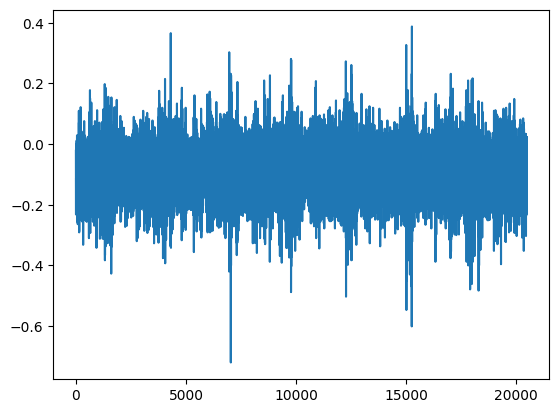

In [ ]:
# Observing the distrubution for the signal at a point of time
plt.plot(data[:,0])
plt.show()

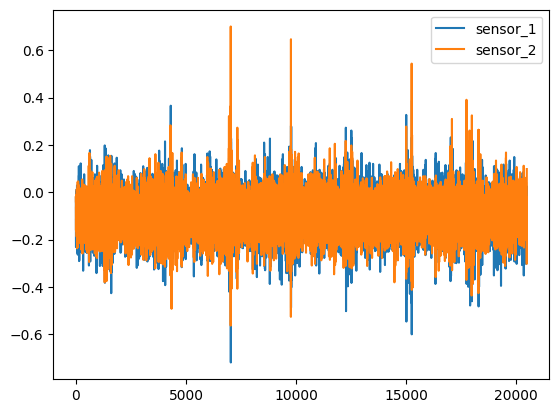

In [ ]:
# Comparing two sensors
plt.plot(data[:,0],label='sensor_1')
plt.plot(data[:,1],label='sensor_2')
plt.legend()

In [ ]:
print(data[:5])

[[-0.022 -0.039 -0.183 -0.054 -0.105 -0.134 -0.129 -0.142]
 [-0.105 -0.017 -0.164 -0.183 -0.049  0.029 -0.115 -0.122]
 [-0.183 -0.098 -0.195 -0.125 -0.005 -0.007 -0.171 -0.071]
 [-0.178 -0.161 -0.159 -0.178 -0.1   -0.115 -0.112 -0.078]
 [-0.208 -0.129 -0.261 -0.098 -0.151 -0.205 -0.063 -0.066]]


In [ ]:
print(data[:,0])


[-0.022 -0.105 -0.183 ... -0.193 -0.115 -0.042]


In [ ]:
signal = data

In [ ]:
# Locating data to another location for better storage
!cp -r "/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/IMS_folder" /content/

In [ ]:
print(os.listdir("/content"))

['.config', 'IMS_folder', 'drive', 'sample_data']


In [ ]:
print(os.listdir("/content/IMS_folder"))

['1st_test', '3rd_test', '2nd_test']


In [ ]:
# Creating the required parameters for the data
base_folder = "/content/IMS_folder"
final_dataset = []

def extract_features(signal):
    feature = {}

    for i in range(signal.shape[1]):
        col = signal[:, i]

        # Time domain features
        feature[f"rms_{i}"] = np.sqrt(np.mean(col**2))
        feature[f"variance_{i}"] = np.var(col)
        feature[f"skewness_{i}"] = pd.Series(col).skew()
        feature[f"kurtosis_{i}"] = pd.Series(col).kurtosis()

        peak_col = np.max(np.abs(col))
        feature[f"crest_factor_{i}"] = peak_col / feature[f"rms_{i}"]

        # Frequency domain features
        fft_vals_col = np.fft.fft(col)
        fft_mag_col = np.abs(fft_vals_col)

        feature[f"fft_energy_{i}"] = np.sum(fft_mag_col**2)

        # Calculate spectral entropy safely for 0s
        prob_col = fft_mag_col / (np.sum(fft_mag_col) + 1e-10)
        feature[f"spectral_entropy_{i}"] = -np.sum(prob_col * np.log2(prob_col + 1e-10))

        feature[f"dominant_freq_{i}"] = np.argmax(fft_mag_col)

    return feature


for subfolder in sorted(os.listdir(base_folder)):
    subfolder_path = os.path.join(base_folder, subfolder)

    if os.path.isdir(subfolder_path):
        for file in sorted(os.listdir(subfolder_path)):

             if not file.startswith('.'):
                file_path = os.path.join(subfolder_path, file)

                try:
                    data = np.loadtxt(file_path)
                except Exception as e:
                    print(f"Skipping {file}: {e}")
                    continue

                features = extract_features(data)

                features["file_name"] = file

                features["source"] = subfolder

                final_dataset.append(features)


df = pd.DataFrame(final_dataset)
df.to_csv("/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/ims_features.csv", index=False)

In [ ]:
print(df.shape)

(9463, 34)


In [ ]:
# Checking for the missing values
df.isnull().sum().value_counts()

,count
0,18
7308,16


In [ ]:
df.isnull().sum()

,0
rms_0,0
kurtosis_0,0
fft_energy_0,0
spectral_entropy_0,0
rms_1,0
kurtosis_1,0
fft_energy_1,0
spectral_entropy_1,0
rms_2,0
kurtosis_2,0


In [ ]:
# Missing values treatment
df = df.drop(columns=[
    'rms_4','kurtosis_4','fft_energy_4','spectral_entropy_4',
    'rms_5','kurtosis_5','fft_energy_5','spectral_entropy_5',
    'rms_6','kurtosis_6','fft_energy_6','spectral_entropy_6',
    'rms_7','kurtosis_7','fft_energy_7','spectral_entropy_7'
])

In [ ]:
df.shape

(9463, 18)

In [ ]:
df.isnull().sum().value_counts()

,count
0,18


In [ ]:
print(df.head(5))

      rms_0  kurtosis_0  fft_energy_0  spectral_entropy_0     rms_1  \
0  0.124614    1.069717  6.513169e+06           13.770654  0.117493   
1  0.123811    1.162128  6.429538e+06           13.791739  0.116833   
2  0.125246    0.986819  6.579459e+06           13.778104  0.118384   
3  0.125197    1.034839  6.574322e+06           13.778700  0.119005   
4  0.125618    1.110728  6.618577e+06           13.770996  0.119688   

   kurtosis_1  fft_energy_1  spectral_entropy_1     rms_2  kurtosis_2  \
0    3.066925  5.790086e+06           13.936363  0.130455    0.209830   
1    2.001798  5.725156e+06           13.944290  0.131490    0.229733   
2    1.969725  5.878265e+06           13.923250  0.131906    0.209045   
3    1.746089  5.940010e+06           13.929479  0.131614    0.189363   
4    1.181742  6.008481e+06           13.926329  0.130779    0.261214   

   fft_energy_2  spectral_entropy_2     rms_3  kurtosis_3  fft_energy_3  \
0  7.138110e+06           13.834722  0.121642    0.292586  

In [ ]:
# Converting date time in the standard formate
df["time"] = pd.to_datetime(df["file_name"], format = '%Y.%m.%d.%H.%M.%S')
df = df.sort_values(by="time").reset_index(drop=True)

#df.to_csv("/content/drive/MyDrive/MASTER_IN_AI_ML/Walsh/Capstone/ims_final_features.csv")

# Data Preprocessing

In [ ]:
# time features and frequency features
time_features = [col for col in df.columns if "rms" in col or "kurtosis" in col]
freq_features = [col for col in df.columns if "fft_energy" in col or "spectral_entropy" in col]

all_features = time_features + freq_features

In [ ]:

split_index = int(0.8 * len(df))

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

In [ ]:
failure_point_train = int(0.8 * len(train_df))

train_df["RUL"] = failure_point_train - train_df.index
train_df["RUL"] = train_df["RUL"].clip(lower=0)

# For test (assume near failure)
test_df["RUL"] = 0

In [ ]:
train_df["label"] = 0
train_df.loc[failure_point_train:, "label"] = 1

# Test = future → mostly faulty

# Create labels properly
failure_point_test = int(0.5 * len(test_df))

labels = np.zeros(len(test_df))
labels[failure_point_test:] = 1

test_df["label"] = labels

# Verify
print(np.unique(test_df["label"], return_counts=True))

(array([0., 1.]), array([946, 947]))


In [ ]:
print(test_df["label"].value_counts())

label
1.0    947
0.0    946
Name: count, dtype: int64


In [ ]:
signal = (signal - np.mean(signal)) / np.std(signal)

In [ ]:
X_train_time = train_df[time_features]
X_test_time = test_df[time_features]

X_train_freq = train_df[freq_features]
X_test_freq = test_df[freq_features]

X_train_combined = train_df[all_features]
X_test_combined = test_df[all_features]

y_train = train_df["label"]
y_test = test_df["label"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

def scale_data(X_train, X_test):
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

X_train_time, X_test_time = scale_data(X_train_time, X_test_time)
X_train_freq, X_test_freq = scale_data(X_train_freq, X_test_freq)
X_train_combined, X_test_combined = scale_data(X_train_combined, X_test_combined)

In [ ]:
print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
0    6056
1    1514
Name: count, dtype: int64
label
1.0    947
0.0    946
Name: count, dtype: int64


# Model building

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(X_train, X_test, y_train, y_test):
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        results[name] = {"Accuracy": acc, "F1": f1}

    return results

# **Research questions**

In [ ]:
print("===== RQ1: Time vs Frequency =====")

res_time = evaluate(X_train_time, X_test_time, y_train, y_test)
res_freq = evaluate(X_train_freq, X_test_freq, y_train, y_test)

print("Time Features:\n", res_time)
print("\nFrequency Features:\n", res_freq)

===== RQ1: Time vs Frequency =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:31:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:31:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Time Features:
 {'Logistic': {'Accuracy': 0.4500792393026941, 'F1': 0.606724593879864}, 'RandomForest': {'Accuracy': 0.32118330692023245, 'F1': 0.47443762781186094}, 'SVM': {'Accuracy': 0.4426835710512414, 'F1': 0.6064901156284969}, 'XGBoost': {'Accuracy': 0.329635499207607, 'F1': 0.48685806712494945}}

Frequency Features:
 {'Logistic': {'Accuracy': 0.3000528262017961, 'F1': 0.42764578833693306}, 'RandomForest': {'Accuracy': 0.3085050184891706, 'F1': 0.4681023973994311}, 'SVM': {'Accuracy': 0.29635499207606975, 'F1': 0.445}, 'XGBoost': {'Accuracy': 0.31642894875858424, 'F1': 0.47948511665325827}}


Result:
        
        Time features: F1 ≈ 0.60 (best)

        Frequency features: F1 ≈ 0.42-0.48

Conclusion:

Time-domain features outperform frequency-domain features for early fault detection, indicating that statistical vibration characteristics (RMS, kurtosis) capture degradation patterns more effectively than spectral features.

In [ ]:
print("\n===== RQ2: Combined vs Single =====")

res_combined = evaluate(X_train_combined, X_test_combined, y_train, y_test)

print("Combined Features:\n", res_combined)


===== RQ2: Combined vs Single =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:32:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Combined Features:
 {'Logistic': {'Accuracy': 0.41627047015319596, 'F1': 0.5767905017234776}, 'RandomForest': {'Accuracy': 0.31378763866877973, 'F1': 0.47087576374745416}, 'SVM': {'Accuracy': 0.35868991019545693, 'F1': 0.5212933753943217}, 'XGBoost': {'Accuracy': 0.32065504490227154, 'F1': 0.4822866344605475}}


Result:

Combined F1 ≈ 0.57

Time alone ≈ 0.60

Conclusion:

Feature fusion did not significantly enhance detection performance, suggesting redundancy or noise in combined feature space.
Combining features did NOT improve performance.

In [ ]:
print("\n===== RQ3: Feature Importance =====")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_combined, y_train)

importances = pd.Series(rf.feature_importances_, index=all_features)
importances = importances.sort_values(ascending=False)

print(importances.head(10))


===== RQ3: Feature Importance =====
fft_energy_1          0.287404
rms_1                 0.226272
spectral_entropy_3    0.095878
fft_energy_3          0.088852
rms_3                 0.057318
spectral_entropy_2    0.045652
spectral_entropy_0    0.044033
rms_2                 0.038039
fft_energy_2          0.036470
fft_energy_0          0.017782
dtype: float64


Top features:

fft_energy_1 (highest)

rms_1

spectral_entropy_3

Conclusion:

Both time and frequency features contribute, but FFT energy and RMS dominate, indicating that energy-based degradation signals are most informative.

In [ ]:
print("\n===== RQ4: Model Comparison =====")

final_results = evaluate(X_train_combined, X_test_combined, y_train, y_test)
print(final_results)


===== RQ4: Model Comparison =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:32:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'Logistic': {'Accuracy': 0.41627047015319596, 'F1': 0.5767905017234776}, 'RandomForest': {'Accuracy': 0.31378763866877973, 'F1': 0.47087576374745416}, 'SVM': {'Accuracy': 0.35868991019545693, 'F1': 0.5212933753943217}, 'XGBoost': {'Accuracy': 0.32065504490227154, 'F1': 0.4822866344605475}}


Best model:

Logistic Regression (F1 ≈ 0.57-0.60)

Conclusion:

Logistic Regression outperformed more complex models, suggesting that the relationship between features and failure is relatively linear.

- The model performance is lower due to temporal generalization challenges, as the test set represents future unseen degradation patterns.
- F1-score was prioritized over accuracy due to class imbalance and the importance of correctly identifying fault conditions


